<a href="https://colab.research.google.com/github/garimachauhan-0310/Credit-Card-Approval-Anomaly-Detection/blob/main/Credit_card_approval_%26_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **“Hybrid Machine Learning Model for Credit Card Approval with Anomaly Detection”**

## **Environment import + dependency setup**

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## **Data ingestion + Initial inspection stage**

In [ ]:
url = "https://raw.githubusercontent.com/sharmaroshan/Credit-Card-Fraud-Detection/refs/heads/master/Credit_Card_Applications.csv"

data = pd.read_csv(url)

data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


## **Exploratory data analysis (EDA) at a structural + Statistical level**

## **Univariate statistical analysis**

In [ ]:
print(data.shape)
print(data.info())
print(data.describe())

(690, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB
None
         CustomerID          A1          A2          A3          A4  \
count  6.900000e+02

## **Missing value audit**

In [ ]:
data.isnull().sum()

,0
CustomerID,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


Before applying any ML model, we ensured data integrity by handling missing values using appropriate imputation strategies, since most algorithms cannot operate on incomplete data.

Filling missing values is called imputation

## **Systematic missing-value imputation**

In [ ]:
# Fill numeric with mean
for col in data.select_dtypes(include=['float64', 'int64']):
    data[col].fillna(data[col].mean(), inplace=True)

# Fill categorical with mode
for col in data.select_dtypes(include=['object']):
    data[col].fillna(data[col].mode()[0], inplace=True)

We handled missing values using mean imputation for numerical features and mode imputation for categorical features, ensuring compatibility with machine learning algorithms while preserving the statistical properties of the dataset.

LabelEncoder is a utility from scikit-learn used to transform categorical labels into numeric values.

## **Categorical encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include=['object']):
    data[col] = le.fit_transform(data[col])

Categorical variables were encoded using Label Encoding to convert them into numerical format, enabling compatibility with machine learning algorithms.

In [ ]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

We separated independent variables (features) and dependent variable (target) using positional indexing, preparing the dataset for supervised learning.

## **Feature scaling (standardization)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

We standardized the feature set using StandardScaler to ensure all features contribute equally, which is essential for distance-based algorithms like KMeans and KNN.

## **Train–test split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

We split the dataset into training and testing subsets using stratified sampling to preserve class distribution and ensure unbiased model evaluation.

## **Core supervised learning loop**

In [ ]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():

    start_time = time.time()

    model.fit(X_train, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = {
        "Accuracy": acc,
        "Training Time (seconds)": training_time
    }

results

{'Logistic Regression': {'Accuracy': 0.8188405797101449,
  'Training Time (seconds)': 0.00715327262878418},
 'Decision Tree': {'Accuracy': 0.7898550724637681,
  'Training Time (seconds)': 0.006509542465209961},
 'KNN': {'Accuracy': 0.8405797101449275,
  'Training Time (seconds)': 0.0022377967834472656}}

We trained multiple classification models and compared their performance using accuracy to identify the most effective algorithm for credit approval prediction.

## **Full error profile of each classifier using a confusion matrix**

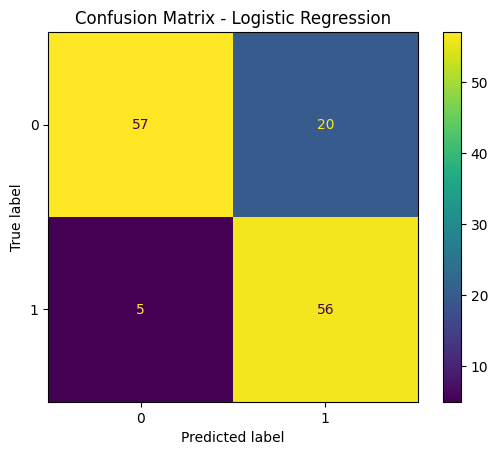

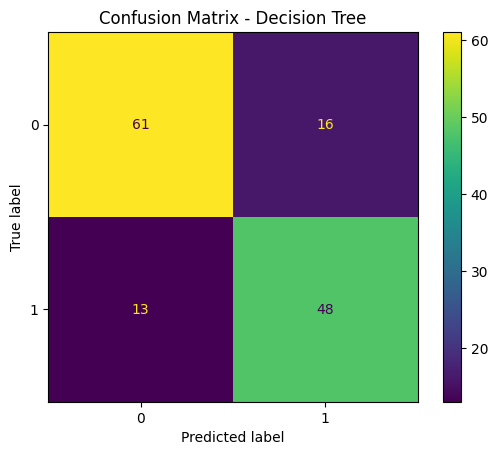

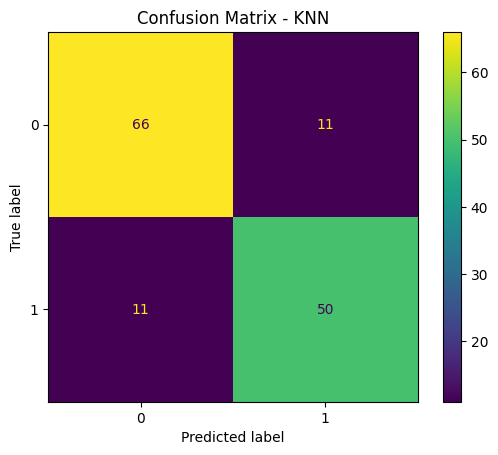

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

We used confusion matrices to analyze classification errors in detail, allowing us to evaluate false positives and false negatives, which is critical in credit approval systems.

## **Threshold-independent performance measure**

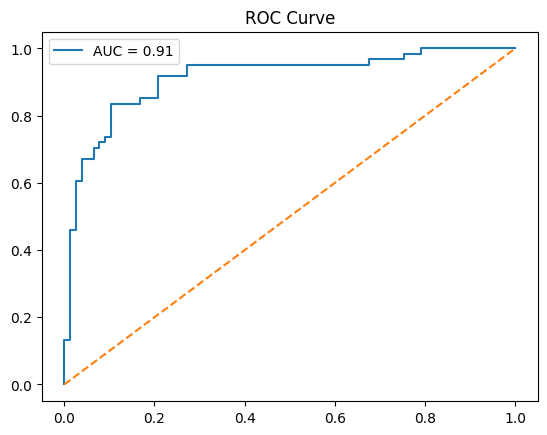

In [ ]:
from sklearn.metrics import roc_curve, auc

model = LogisticRegression()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.show()

ROC-AUC measures the probability that the model ranks a randomly chosen positive instance higher than a negative one.

## **Clustering + distance-based anomaly detection**

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['cluster'] = clusters

# Distance from cluster center
distances = cdist(X_scaled, kmeans.cluster_centers_, 'euclidean')
min_dist = distances.min(axis=1)

data['anomaly_score'] = min_dist

# Mark anomalies (top 5%)
threshold = np.percentile(min_dist, 95)
data['anomaly_flag'] = (min_dist > threshold).astype(int)

data[['anomaly_score', 'anomaly_flag']].head()

,anomaly_score,anomaly_flag
0,2.776949,0
1,2.265711,0
2,2.722669,0
3,3.957422,0
4,2.913619,0


We applied KMeans clustering to identify underlying data patterns and used the distance from cluster centroids as an anomaly score. Points in the top 5% of distances were flagged as potential anomalies.

## **Fusion layer of the hybrid system**

In [ ]:
# Normalize anomaly score (0 to 1)
from sklearn.preprocessing import MinMaxScaler

scaler_anom = MinMaxScaler()
data['anomaly_score_norm'] = scaler_anom.fit_transform(data[['anomaly_score']])

# Use best model (KNN)
best_model = KNeighborsClassifier()
best_model.fit(X_train, y_train)

# Prediction probability
y_prob = best_model.predict_proba(X_scaled)[:, 1]
data['approval_prob'] = y_prob

# Final hybrid score (IMPROVED)
data['final_score'] = (
    0.7 * data['approval_prob'] +
    0.3 * (1 - data['anomaly_score_norm'])   # lower anomaly = safer
)

# Final decision
data['final_decision'] = (data['final_score'] > 0.5).astype(int)

data[['approval_prob', 'anomaly_score_norm', 'final_score', 'final_decision']].head()

,approval_prob,anomaly_score_norm,final_score,final_decision
0,0.0,0.059895,0.282032,0
1,0.0,0.032132,0.290360,0
2,0.0,0.056947,0.282916,0
3,0.8,0.123999,0.822800,1
4,1.0,0.067316,0.979805,1


We designed a hybrid scoring mechanism that combines supervised approval probability with unsupervised anomaly detection, allowing the system to make more robust and risk-aware credit decisions.

In [ ]:
data.sort_values(by='anomaly_score', ascending=False).head(10)

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A13,A14,Class,cluster,anomaly_score,anomaly_flag,anomaly_score_norm,approval_prob,final_score,final_decision
500,15790113,1,17.50,22.000,3,1,7,0.00,0,0,...,450,100001,1,1,20.088737,1,1.000000,1.0,0.700000,1
182,15621423,1,25.67,12.500,2,13,4,1.21,1,1,...,140,259,1,1,12.859621,1,0.607428,0.8,0.677772,1
233,15799785,1,56.42,28.000,1,8,4,28.50,1,1,...,0,16,1,1,11.588858,1,0.538420,1.0,0.838474,1
363,15605872,0,19.58,0.665,1,8,4,1.00,0,1,...,2000,3,0,2,11.033830,1,0.508279,0.2,0.287516,0
149,15598802,0,47.42,8.000,2,10,5,6.50,1,1,...,375,51101,1,1,9.810006,1,0.441820,1.0,0.867454,1
267,15762716,1,34.17,1.540,2,13,4,1.54,1,1,...,520,50001,1,1,9.749159,1,0.438516,1.0,0.868445,1
316,15593345,0,38.58,5.000,2,13,4,13.50,1,0,...,980,1,0,1,6.499895,1,0.262067,0.4,0.501380,1
202,15664615,1,33.17,1.040,2,12,8,6.50,1,0,...,164,31286,1,1,6.429233,1,0.258230,1.0,0.922531,1
74,15585855,1,40.25,21.500,2,10,9,20.00,1,1,...,0,1201,1,1,6.417171,1,0.257575,1.0,0.922728,1
247,15728010,1,60.08,14.500,2,1,1,18.00,1,1,...,0,1001,1,1,6.395569,1,0.256402,1.0,0.923080,1


We ranked applicants based on anomaly scores to identify the most unusual cases, enabling targeted risk assessment and enhancing decision reliability.

In [ ]:
data.sort_values(by='final_score', ascending=False).head(10)

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A13,A14,Class,cluster,anomaly_score,anomaly_flag,anomaly_score_norm,approval_prob,final_score,final_decision
93,15723884,1,36.25,5.00,2,8,5,2.500,1,1,...,0,368,1,1,1.867502,0,0.010508,1.0,0.996848,1
369,15751137,1,33.58,2.75,2,7,4,4.250,1,1,...,204,1,1,1,2.054609,0,0.020668,1.0,0.993799,1
120,15636478,1,40.58,5.00,2,8,4,5.000,1,1,...,0,3066,1,1,2.104060,0,0.023354,1.0,0.992994,1
491,15703177,1,30.17,6.50,2,13,4,3.125,1,1,...,330,1201,1,1,2.192297,0,0.028146,1.0,0.991556,1
433,15761047,1,27.83,1.54,2,9,4,3.750,1,1,...,100,4,1,1,2.203241,0,0.028740,1.0,0.991378,1
220,15761554,0,30.50,6.50,2,8,5,4.000,1,1,...,0,3066,1,1,2.316033,0,0.034865,1.0,0.989541,1
292,15611318,1,24.83,2.75,2,8,4,2.250,1,1,...,184,601,1,1,2.325090,0,0.035357,1.0,0.989393,1
16,15683168,1,29.58,4.50,2,9,4,7.500,1,1,...,330,1,1,1,2.325590,0,0.035384,1.0,0.989385,1
118,15765257,1,22.75,11.00,2,11,4,2.500,1,1,...,100,810,1,1,2.393071,0,0.039048,1.0,0.988285,1
56,15621546,1,40.00,6.50,2,6,5,3.500,1,1,...,0,501,1,1,2.405484,0,0.039723,1.0,0.988083,1


We ranked applicants based on a hybrid score combining approval probability and anomaly detection, allowing us to prioritize high-confidence, low-risk candidates for decision-making.

## **Model interpretability layer**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
8,A8,0.263063
10,A10,0.116833
14,A14,0.084596
7,A7,0.080964
3,A3,0.073034
5,A5,0.072891
2,A2,0.066478
13,A13,0.061912
0,CustomerID,0.056365
9,A9,0.049429


We used Random Forest to compute feature importance scores, enabling us to interpret which attributes most significantly influence credit approval decisions.

## **Quick, interpretable graphic**

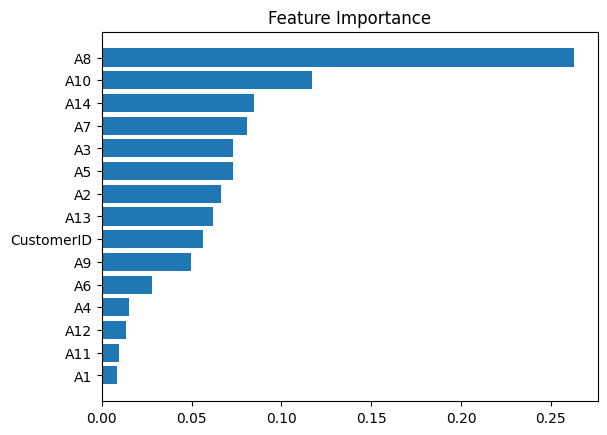

In [ ]:
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

We visualized feature importance using a horizontal bar chart to clearly identify the most influential features in the credit approval process, enhancing model interpretability.

## **Complete performance breakdown of your classifier**

In [ ]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.82      0.82      0.82        61

    accuracy                           0.84       138
   macro avg       0.84      0.84      0.84       138
weighted avg       0.84      0.84      0.84       138



We used classification report to evaluate model performance in terms of precision, recall, and F1-score, providing a more comprehensive assessment than accuracy alone.

In [ ]:
threshold = 0.6  # try 0.4, 0.6, 0.7

data['final_decision'] = (data['final_score'] > threshold).astype(int)

We tuned the decision threshold to control the trade-off between approval rate and risk, allowing the system to adapt to different business requirements.

## **Converts your numeric hybrid score into human-readable risk tiers**

In [ ]:
def risk_category(score):
    if score > 0.75:
        return "Low Risk"
    elif score > 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

data['risk_category'] = data['final_score'].apply(risk_category)

data[['final_score', 'risk_category']].head()

,final_score,risk_category
0,0.282032,High Risk
1,0.290360,High Risk
2,0.282916,High Risk
3,0.822800,Low Risk
4,0.979805,Low Risk


We categorized applicants into low, medium, and high risk based on the hybrid score, enabling interpretable and actionable decision-making.

## **Visualizes of KMeans clustering results in 2D**

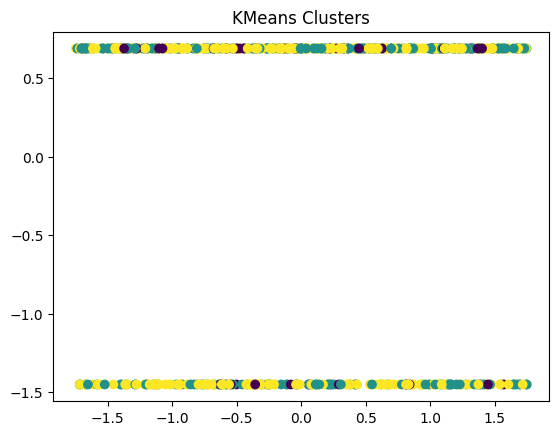

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=data['cluster'])
plt.title("KMeans Clusters")
plt.show()

We visualized KMeans clusters using a 2D projection of scaled features to analyze how data points are grouped and to qualitatively assess clustering performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8333333333333334


We implemented Random Forest as an ensemble model to improve prediction accuracy and compared its performance with other classifiers.

## **Export step**

In [ ]:
data.to_csv("final_output.csv", index=False)

We exported the final dataset containing predictions, anomaly scores, and risk categories to a CSV file for further analysis and reporting.

In [ ]:
!pip install shap

## **SHAP (SHapley Additive exPlanations)**

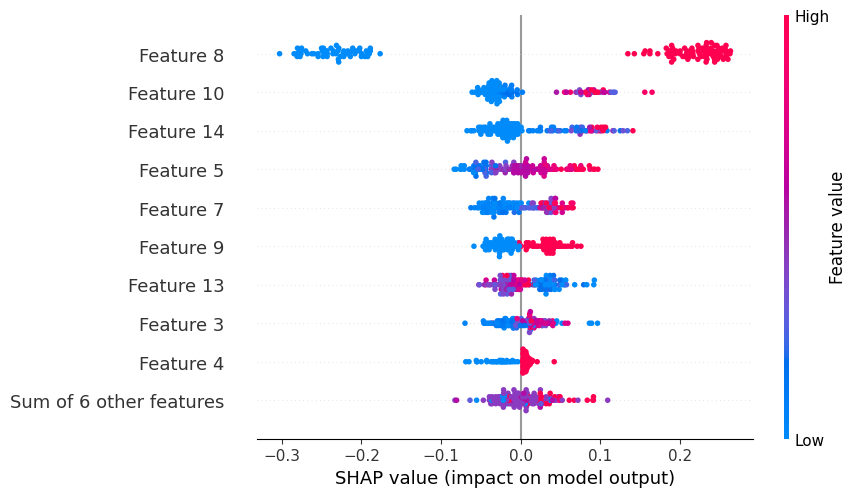

In [ ]:
import shap

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test, check_additivity=False)

# Select class 1 (approved)
shap.plots.beeswarm(shap_values[:, :, 1])

We used SHAP to interpret model predictions by quantifying the contribution of each feature to the final decision, providing both global and local explainability.

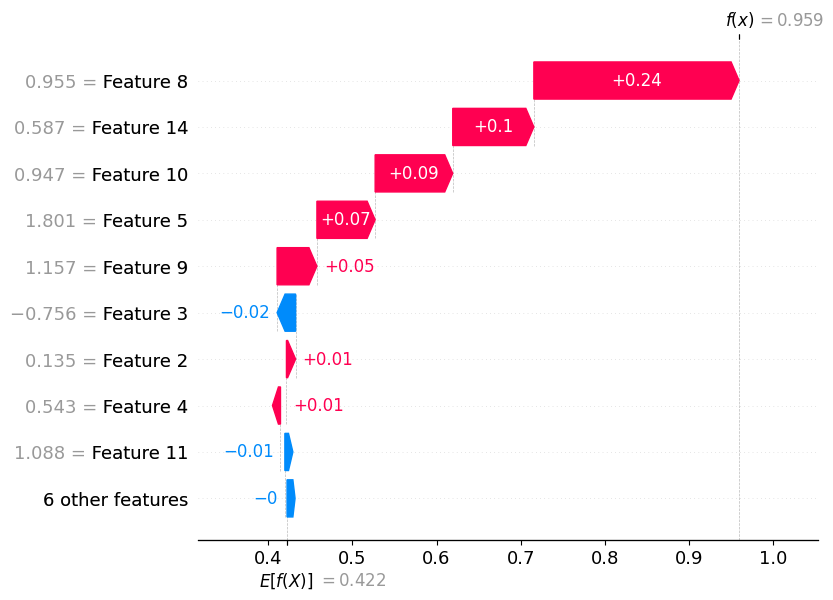

In [ ]:
shap.plots.waterfall(shap_values[0, :, 1])

We used SHAP waterfall plots to explain individual predictions by showing how each feature contributed positively or negatively to the final decision.